# Librerías

In [ ]:
import pandas as pd
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import normalize

# **Carga de datos**

In [ ]:
# Carga del dataset desde github
url = "https://raw.githubusercontent.com/JeiGeek/Replica_clasificacion_multimodal_parkinson/main/requirements/MDS-UPDRS_Part_III_28Oct2025_estandarizado_pd_mbrs.csv"
df = pd.read_csv(url)

In [ ]:
# Asignacion de tabla "grupo" para pacientes de parkinson
df["grupo"] = 1
df.head()

,PATNO,EVENT_ID,PDTRTMNT,PDSTATE,HRPOSTMED,HRDBSON,HRDBSOFF,PDMEDYN,DBSYN,ONOFFORDER,...,NP3RTCON,NP3TOT,DYSKPRES,DYSKIRAT,NHY,SEX,AGE_AT_VISIT,COHORT_DEFINITION,MBRS,grupo
0,3001,V17,1.0,1.0,1.0000,NaN,NaN,1.0,0.0,1.0,...,0.0,40.0,1.0,0.0,2.0,1,82.7,Parkinson's Disease,13.0,1
1,3002,V17,1.0,1.0,0.8333,NaN,NaN,1.0,0.0,1.0,...,0.0,31.0,1.0,0.0,4.0,0,82.7,Parkinson's Disease,14.0,1
2,3003,V21,1.0,1.0,1.2500,NaN,NaN,1.0,0.0,NaN,...,0.0,25.0,1.0,0.0,2.0,0,63.9,Parkinson's Disease,8.0,1
3,3005,SC,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,0.0,5.0,0.0,NaN,0.0,0,61.7,Parkinson's Disease,0.0,1
4,3006,V04,1.0,1.0,1.0000,NaN,NaN,1.0,0.0,NaN,...,0.0,34.0,0.0,NaN,2.0,0,56.7,Parkinson's Disease,14.0,1


#**Analisis de los datos**

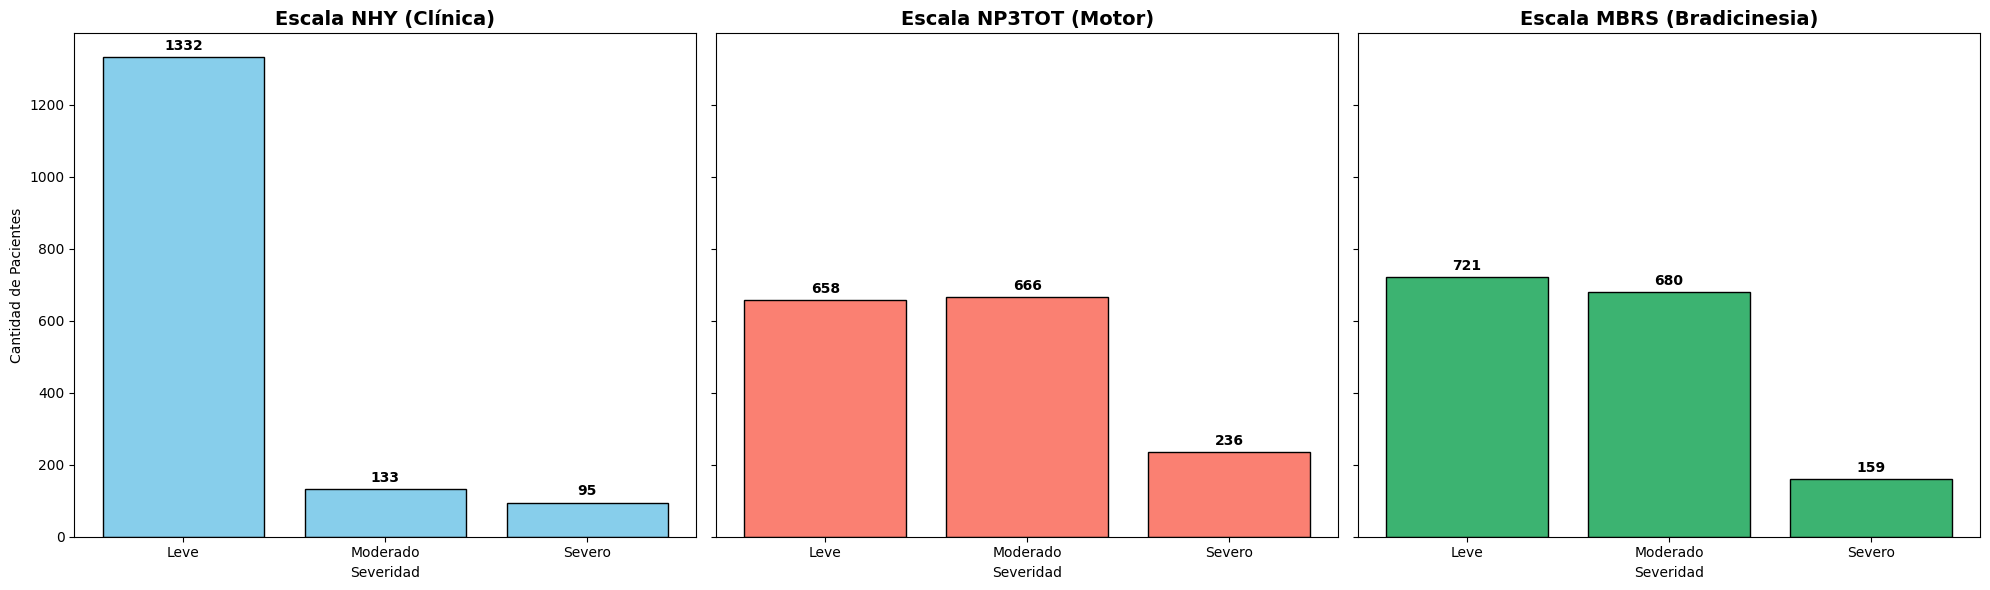

In [ ]:
import matplotlib.pyplot as plt

# funciones de clasificación
def clasificar_nhy(nhy):
    if nhy <= 2:
        return "Leve"
    elif nhy == 3:
        return "Moderado"
    else:
        return "Severo"

def clasificar_np3(score):
    if score <= 20:
        return "Leve"
    elif score <= 40:
        return "Moderado"
    else:
        return "Severo"

def clasificar_mbrs(score):
    if score <= 5:
        return "Leve"
    elif score <= 12:
        return "Moderado"
    else:
        return "Severo"

# columnas por separado
df["SEVERIDAD_NHY"] = df["NHY"].apply(clasificar_nhy)
df["SEVERIDAD_NP3"] = df["NP3TOT"].apply(clasificar_np3)
df["SEVERIDAD_MBRS"] = df["MBRS"].apply(clasificar_mbrs)

# orden lógico para las barras
orden_logico = ["Leve", "Moderado", "Severo"]


fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

#  NHY
counts_nhy = df["SEVERIDAD_NHY"].value_counts().reindex(orden_logico)
axes[0].bar(counts_nhy.index, counts_nhy.values, color='skyblue', edgecolor='black')
axes[0].set_title("Escala NHY (Clínica)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Cantidad de Pacientes")
axes[0].bar_label(axes[0].containers[0], padding=3, fontweight='bold')

#  NP3TOT
counts_np3 = df["SEVERIDAD_NP3"].value_counts().reindex(orden_logico)
axes[1].bar(counts_np3.index, counts_np3.values, color='salmon', edgecolor='black')
axes[1].set_title("Escala NP3TOT (Motor)", fontsize=14, fontweight='bold')
axes[1].bar_label(axes[1].containers[0], padding=3, fontweight='bold')

# MBRS
counts_mbrs = df["SEVERIDAD_MBRS"].value_counts().reindex(orden_logico)
axes[2].bar(counts_mbrs.index, counts_mbrs.values, color='mediumseagreen', edgecolor='black')
axes[2].set_title("Escala MBRS (Bradicinesia)", fontsize=14, fontweight='bold')
axes[2].bar_label(axes[2].containers[0], padding=3, fontweight='bold')


for ax in axes:
    ax.set_xlabel("Severidad")

plt.tight_layout()
plt.show()

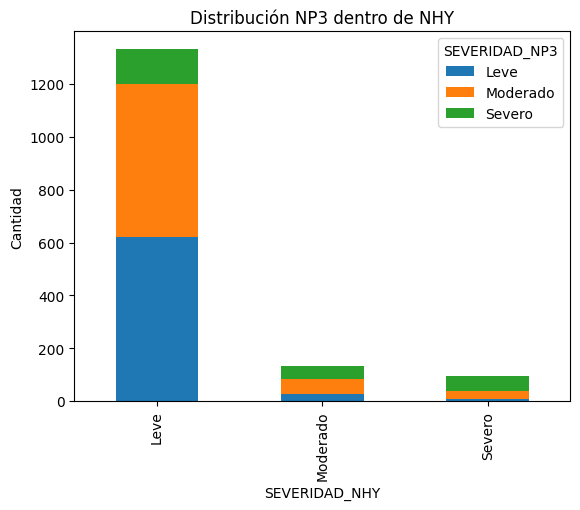

In [ ]:
tabla = pd.crosstab(df['SEVERIDAD_NHY'], df['SEVERIDAD_NP3'])

tabla.plot(kind='bar', stacked=True)

plt.title('Distribución NP3 dentro de NHY')
plt.xlabel('SEVERIDAD_NHY')
plt.ylabel('Cantidad')
plt.show()

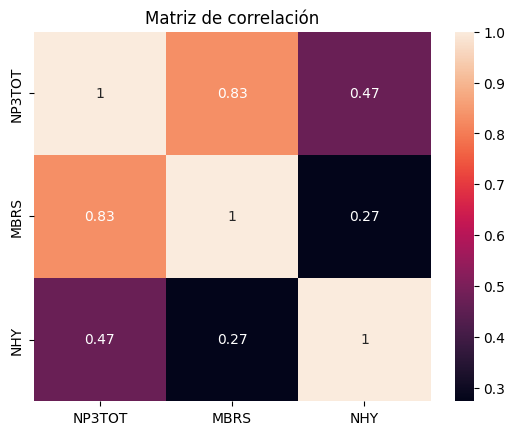

In [ ]:
variables = ['NP3TOT', 'MBRS', 'NHY']

corr = df[variables].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title('Matriz de correlación')
plt.show()

In [ ]:
# porque se necesita colocar 1?????????

**Tabulares basados en:**
* Información Demográfica
* Evaluación Motora
* Movimientos de Manos
* Movimientos de Piernas
* Rigidez
* Temblor
* Puntuación Global
* Tratamiento y Estado Clínico
* Estimulación Cerebral Profunda (DBS)
* Discinesias
* Evaluaciones ON / OFF
* Estadificación de la Enfermedad

In [ ]:
# Creación de descripciones de los nombres de cada una de las caracteristicas
descripciones_en = {
    'Edad': 'age', 'Genero': 'gender', 'NP3BRADY': 'bradykinesia',
    'NP3FACXP': 'reduced facial expression', 'NP3FRZGT': 'freezing of gait',
    'NP3FTAPL': 'left foot tapping', 'NP3FTAPR': 'right foot tapping',
    'NP3GAIT': 'gait impairment', 'NP3HMOVL': 'left hand movement',
    'NP3HMOVR': 'right hand movement', 'NP3KTRML': 'left hand kinesia',
    'NP3KTRMR': 'right hand kinesia', 'NP3LGAGL': 'left leg agility',
    'NP3LGAGR': 'right leg agility', 'NP3POSTR': 'posture',
    'NP3PRSPL': 'left hand postural tremor', 'NP3PRSPR': 'right hand postural tremor',
    'NP3PSTBL': 'postural instability', 'NP3PTRML': 'left hand resting tremor',
    'NP3PTRMR': 'right hand resting tremor', 'NP3RIGLL': 'left leg rigidity',
    'NP3RIGLU': 'left arm rigidity', 'NP3RIGN': 'neck rigidity',
    'NP3RIGRL': 'right leg rigidity', 'NP3RIGRU': 'right arm rigidity',
    'NP3RISNG': 'difficulty rising from chair', 'NP3RTALJ': 'left leg action tremor',
    'NP3RTALL': 'left leg action tremor', 'NP3RTALU': 'left arm action tremor',
    'NP3RTARL': 'right leg action tremor', 'NP3RTARU': 'right arm action tremor',
    'NP3RTCON': 'tremor constancy', 'NP3SPCH': 'speech impairment',
    'NP3TOT': 'MDS-UPDRS III total score', 'NP3TTAPL': 'left hand tapping',
    'NP3TTAPR': 'right hand tapping', 'DBSYN': 'deep brain stimulation symptoms',
    'DYSKPRES': 'dyskinesia presence', 'MBRS': 'dyskinesia scale',
    'H & Y Stage': 'Hoehn & Yahr stage', 'NHY': 'numeric Hoehn & Yahr stage',
    'DBSOFFTM': 'time DBS switched off', 'DBSONTM': 'time DBS switched on',
    'HRDBSOFF': 'hours from DBS off to NUPDRS3 exam',
    'HRDBSON': 'hours from DBS on to NUPDRS3 exam',
    'HRPOSTMED': 'hours from last PD medication to NUPDRS3 exam',
    'OFFEXAM': 'OFF exam performed', 'OFFNORSN': 'reason OFF exam not performed',
    'ONEXAM': 'ON exam performed', 'ONNORSN': 'reason ON exam not performed',
    'ONOFFORDER': 'order of OFF/ON Part III exams', 'PDMEDYN': 'Parkinson medication',
    'PDSTATE': 'current functional state', 'PDTRTMNT': 'treatment received',
    'Pat_id': 'patient ID', 'grupo': 'patient group'
}

# **Generación de prompts**

In [ ]:
# Función de creación de prompts
def crear_prompts_parkinson(df, descripciones, idioma="es"):
    prompts = []
    for _, row in df.iterrows():

        # identificacion del idioma
        if idioma == "es":
          tipo_paciente = "paciente con Parkinson" if row['grupo'] == 1 else "control"
        else:
          tipo_paciente = "Parkinson's patient" if row['grupo'] == 1 else "control subject"

        prompt_parts = [f"{tipo_paciente}:"]

        # Construcción de prompots y tratamiento de valores nulos
        for col in df.columns:
            valor = row[col]

            if pd.isna(valor):
                valor = "no informado" if idioma == "es" else "not reported"
            else:
                if col == 'Genero':
                    if idioma == "es":
                        valor = "masculino" if valor == 1 else "femenino"
                    else:
                        valor = "male" if valor == 1 else "female"

            if col in descripciones:
                desc = descripciones[col]
                prompt_parts.append(f"{desc}: {valor}")
            else:
                prompt_parts.append(f"{col}: {valor}")

        prompts.append(". ".join(prompt_parts))
    return prompts

In [ ]:
# Guardar prompts en inglés en columnas del DataFrame
df["prompts_400_ing"] = crear_prompts_parkinson(df, descripciones_en, idioma="en")

# Ver primeros 3 pacientes
for i in range(3):
    print(f"\nPaciente {i+1} (EN):\n{df['prompts_400_ing'].iloc[i]}")


Paciente 1 (EN):
Parkinson's patient:. PATNO: 3001. EVENT_ID: V17. treatment received: 1.0. current functional state: 1.0. hours from last PD medication to NUPDRS3 exam: 1.0. hours from DBS on to NUPDRS3 exam: not reported. hours from DBS off to NUPDRS3 exam: not reported. Parkinson medication: 1.0. deep brain stimulation symptoms: 0.0. order of OFF/ON Part III exams: 1.0. OFF exam performed: not reported. reason OFF exam not performed: not reported. DBSOFFYN: not reported. time DBS switched off: not reported. ON exam performed: 1.0. reason ON exam not performed: not reported. HIFUYN: not reported. DBSONYN: not reported. time DBS switched on: not reported. speech impairment: 2.0. reduced facial expression: 1.0. neck rigidity: 3.0. right arm rigidity: 1.0. left arm rigidity: 2.0. right leg rigidity: 1.0. left leg rigidity: 2.0. right foot tapping: 3.0. left foot tapping: 2.0. right hand movement: 3.0. left hand movement: 2.0. right hand postural tremor: 2.0. left hand postural tremor: 

In [ ]:
# Generacion de archivo csv de los prompts
df[['PATNO', 'grupo', 'prompts_400_ing']].to_csv(
    "prompts_400_ing.csv",
    index=False,
    encoding='utf-8'
)

# **Extracción de embeddings**

In [ ]:
!pip install transformers torch scikit-learn pandas
url_prompts = "https://raw.githubusercontent.com/JeiGeek/Replica_clasificacion_multimodal_parkinson/main/requirements/prompts_400_ing.csv"
#url_original = "https://raw.githubusercontent.com/JeiGeek/Replica_clasificacion_multimodal_parkinson/main/requirements/MDS-UPDRS_Part_III_28Oct2025_estandarizado_pd_mbrs.csv"

dfp = pd.read_csv(url_prompts)
#dfo = pd.read_csv(url_original)

In [ ]:
#modelo clinicalBERT
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
model = AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

model.to(device)
model.eval()

batch_size = 8

all_embeddings = []

texts = df["prompts_400_ing"].tolist()

#Tokenizar
for i in range(0, len(texts), batch_size):
    batch_texts = texts[i:i+batch_size]

    inputs = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    #Se le pasa a clinicalBERT

    with torch.no_grad():
        outputs = model(**inputs)
    #CLS
    cls_embeddings = outputs.last_hidden_state[:, 0, :]
    cls_embeddings = cls_embeddings.cpu().numpy()

    all_embeddings.append(cls_embeddings)

# Concatenar todos los batches
all_embeddings = np.vstack(all_embeddings)

# L2 normalization
all_embeddings = normalize(all_embeddings, norm="l2")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:

# Convertir embeddings a array de NumPy
embeddings_array = np.array(all_embeddings)
patno_array = np.array(df["PATNO"].values)

# Guardar todo en un solo archivo .npz - para poder utilizarlo en otro modelo
np.savez("clinicalbert_data.npz", patno=patno_array, embeddings=embeddings_array)

In [ ]:
# Crear DataFrame final-si lo quiere para visualizar
df_embeddings = pd.DataFrame(all_embeddings)
df_embeddings.insert(0, "PATNO", df["PATNO"].values)

df_embeddings.to_csv("clinicalbert_embeddings.csv", index=False)

# **Experimentación**

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

CV-5 | acc=0.768±0.136  f1_macro=0.765±0.148

=== Test PD: Leve/Moderado/Grave ===
              precision    recall  f1-score   support

        Leve      1.000     1.000     1.000         3
    Moderado      0.875     0.778     0.824         9
       Grave      0.600     0.750     0.667         4

    accuracy                          0.812        16
   macro avg      0.825     0.843     0.830        16
weighted avg      0.830     0.812     0.817        16



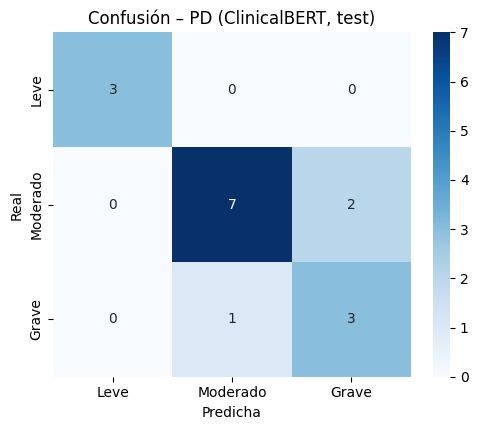

Train PD: 64 | Test PD: 16 | Device: cpu


In [2]:

#clasificacion de Pacientes de Parkinson utilizando clinicalBERT de forma supervisada

!pip install -q sentence-transformers scikit-learn pandas seaborn matplotlib transformers

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer, models
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score


url_prompts  = "https://raw.githubusercontent.com/JeiGeek/Replica_clasificacion_multimodal_parkinson/main/requirements/prompts_400_ing.csv"
url_original = "https://raw.githubusercontent.com/JeiGeek/Replica_clasificacion_multimodal_parkinson/main/requirements/MDS-UPDRS_Part_III_28Oct2025_estandarizado_pd_mbrs.csv"

dfp = pd.read_csv(url_prompts)
dfo = pd.read_csv(url_original)


# merge: prompts + MBRS

df = dfp.merge(dfo[['PATNO','MBRS']], on='PATNO', how='left')

if 'grupo' in df.columns:
    df = df[df['grupo'] == 1].copy()

# Convertir MBRS en clases de gravedad
def clase_pd(m):
    if pd.isna(m): return -1
    if m <= 5: return 1       # Leve
    if 6 <= m <= 12: return 2 # Moderado
    if 13 <= m <= 24: return 3 # Grave
    return -1

df['clase_gravedad'] = df['MBRS'].apply(clase_pd)
df = df[df['clase_gravedad'] != -1].copy()


# Split fijo usando listas de IDs

test_ids  = ['3105','3127','3166','3179','3181','3354','3392','3556','3577','3815','3818','3832','3867','4001','4080','51632']
train_ids = ['3102','3107','3108','3111','3113','3120','3124','3128','3134','3167','3174','3178','3307','3309','3311','3314',
             '3321','3322','3323','3327','3328','3360','3364','3366','3380','3383','3552','3557','3564','3575','3585','3586',
             '3753','3760','3764','3771','3780','3789','3800','3814','3822','3826','3830','3863','4005','4006','4019','4024',
             '4025','4026','4030','4034','4035','40533','4069','40781','4081','4082','4083','40916','41486','41829','50028','51731']

# Filtrar solo IDs que existen en el dataset
pd_ids = set(df['PATNO'].astype(str))
train_ids = [i for i in train_ids if i in pd_ids]
test_ids  = [i for i in test_ids  if i in pd_ids]

df_train = df[df['PATNO'].astype(str).isin(train_ids)].copy()
df_test  = df[df['PATNO'].astype(str).isin(test_ids)].copy()
assert not df_train.empty and not df_test.empty, f"Split vacío. train={len(df_train)} test={len(df_test)}"


# Embeddings ClinicalBERT

device   = "cuda" if torch.cuda.is_available() else "cpu"
backbone = "emilyalsentzer/Bio_ClinicalBERT"
wb = models.Transformer(backbone, max_seq_length=512)
pool = models.Pooling(wb.get_word_embedding_dimension(), pooling_mode_mean_tokens=True)
embedder = SentenceTransformer(modules=[wb, pool], device=device)

X_train = embedder.encode(df_train['prompts_400_ing'].tolist(), batch_size=32, normalize_embeddings=True,
                          convert_to_numpy=True, show_progress_bar=True)
X_test  = embedder.encode(df_test['prompts_400_ing'].tolist(),  batch_size=32, normalize_embeddings=True,
                          convert_to_numpy=True, show_progress_bar=True)
y_train = df_train['clase_gravedad'].values
y_test  = df_test['clase_gravedad'].values


# Validación cruzada en train (k-fold estratificado)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs, f1mac = [], []

for tr, va in skf.split(X_train, y_train):
    clf_cv = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
    clf_cv.fit(X_train[tr], y_train[tr])
    yp = clf_cv.predict(X_train[va])
    accs.append(accuracy_score(y_train[va], yp))
    f1mac.append(f1_score(y_train[va], yp, average='macro'))

print(f"CV-5 | acc={np.mean(accs):.3f}±{np.std(accs):.3f}  f1_macro={np.mean(f1mac):.3f}±{np.std(f1mac):.3f}")


#  Entrenar final y evaluar en test

clf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("\n=== Test PD: Leve/Moderado/Grave ===")
print(classification_report(y_test, y_pred, labels=[1,2,3],
                            target_names=["Leve","Moderado","Grave"], digits=3))

cm = confusion_matrix(y_test, y_pred, labels=[1,2,3])
cm_df = pd.DataFrame(cm, index=["Leve","Moderado","Grave"], columns=["Leve","Moderado","Grave"])

plt.figure(figsize=(5.2,4.4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.ylabel("Real"); plt.xlabel("Predicha"); plt.title("Confusión – PD (ClinicalBERT, test)")
plt.tight_layout(); plt.show()

print(f"Train PD: {len(df_train)} | Test PD: {len(df_test)} | Device: {device}")